In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

#Load data
df = pd.read_csv("master_dataset.csv")
df.head()


,Year,Quarter_Label,PeriodEndDate,ReportType,Y_Cost_Per_Ton,Gross_Margin_Pct,AccessionNumber,Cost_of_products_sold,Net_sales,Inventories_net,...,X3_Natural_Gas_Price,X4_Diesel_Price,X5_Rail_Price,X6_Disaster_Cost_Sum,X7_Hourly_Wage,X8_US_Scrap_Exports,X9_US_Dollar_Index,X10_Graphite_Price,X11_Economic_Policy_Uncertainty,X12_Inventory_Turnover
0,2015,Q1,2015-04-04,10-Q,729.575510,6.552698,0001193125-15-185690,4.111158e+09,4.399440e+09,2.405916e+09,...,2.896667,2.917333,182.600000,9998.6,24.800000,2.258731e+09,105.473017,162.466667,101.377553,1.596272
1,2015,Q2,2015-07-04,10-Q,655.871676,8.865091,0001193125-15-287733,3.971303e+09,4.357609e+09,2.267394e+09,...,2.746667,2.847667,179.833333,15643.9,24.943333,2.719429e+09,105.997159,161.400000,107.247981,1.699568
2,2015,Q3,2015-10-03,10-Q,629.216046,12.396977,0001193125-15-374781,3.701678e+09,4.225514e+09,2.361071e+09,...,2.756667,2.629333,178.800000,0.0,25.070000,2.308197e+09,109.626666,161.000000,142.390361,1.599527
3,2015,Q4,2015-12-31,Calculated_Q4,656.977971,1.636830,0001193125-16-481119,3.399861e+09,3.456437e+09,2.145444e+09,...,2.120000,2.432000,176.666667,5266.9,25.233333,1.985767e+09,111.474224,160.200000,100.749685,1.508865
4,2016,Q1,2016-04-02,10-Q,557.681848,7.722840,0001193125-16-586874,3.428628e+09,3.715576e+09,2.007879e+09,...,2.000000,2.077000,174.000000,13371.5,25.400000,1.592065e+09,113.609032,159.433333,144.556417,1.651029


In [ ]:
#Structure and Summary
print("Dataset shape:", df.shape)
df.info()

df.describe(include="all").T


Dataset shape: (43, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             43 non-null     int64  
 1   Quarter_Label                    43 non-null     object 
 2   PeriodEndDate                    43 non-null     object 
 3   ReportType                       43 non-null     object 
 4   Y_Cost_Per_Ton                   43 non-null     float64
 5   Gross_Margin_Pct                 43 non-null     float64
 6   AccessionNumber                  43 non-null     object 
 7   Cost_of_products_sold            43 non-null     float64
 8   Net_sales                        43 non-null     float64
 9   Inventories_net                  43 non-null     float64
 10  Tons_Shipped                     43 non-null     float64
 11  Inventories_Previous             43 non-null     float64
 12  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,43.0,NaN,NaN,NaN,2019.883721,3.141196,2015.0,2017.0,2020.0,2022.5,2025.0
Quarter_Label,43,4,Q1,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PeriodEndDate,43,43,2015-04-04,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ReportType,43,2,10-Q,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y_Cost_Per_Ton,43.0,NaN,NaN,NaN,898.216528,309.093693,557.681848,695.003503,773.560159,1072.466829,2349.060992
Gross_Margin_Pct,43.0,NaN,NaN,NaN,13.33613,10.428268,-12.801733,8.607295,13.337033,18.927216,34.798186
AccessionNumber,43,43,0001193125-15-185690,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cost_of_products_sold,43.0,NaN,NaN,NaN,5680227279.069767,1501150621.823891,3399861000.0,4445454500.0,5394703000.0,6895033500.0,8884282000.0
Net_sales,43.0,NaN,NaN,NaN,6719671116.27907,2206425996.933041,3456437000.0,5009947500.0,6295605000.0,8488500000.0,11794474000.0
Inventories_net,43.0,NaN,NaN,NaN,4272765325.581395,1310810326.201765,2007879000.0,3349910500.0,4268799000.0,5423265500.0,6579142000.0


In [ ]:
#Outlier detection

numeric_cols = df.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outliers"])
outlier_summary.sort_values("Outliers", ascending=False)


,Outliers
X3_Natural_Gas_Price,7
X11_Economic_Policy_Uncertainty,6
X6_Disaster_Cost_Sum,5
Tons_Shipped_thousands,3
Tons_Shipped,3
Gross_Margin_Pct,2
X4_Diesel_Price,1
Y_Cost_Per_Ton,1
X2_Electricity_Price,0
X10_Graphite_Price,0


In [ ]:
#Define target (Y)and key feature (Y1)

TARGET = "Cost_of_products_sold"  # main forecasting target
Y1 = "Y_Cost_Per_Ton"             # key explanatory variable

print("Target (Y):", TARGET)
print("Key feature (Y1):", Y1)


Target (Y): Cost_of_products_sold
Key feature (Y1): Y_Cost_Per_Ton


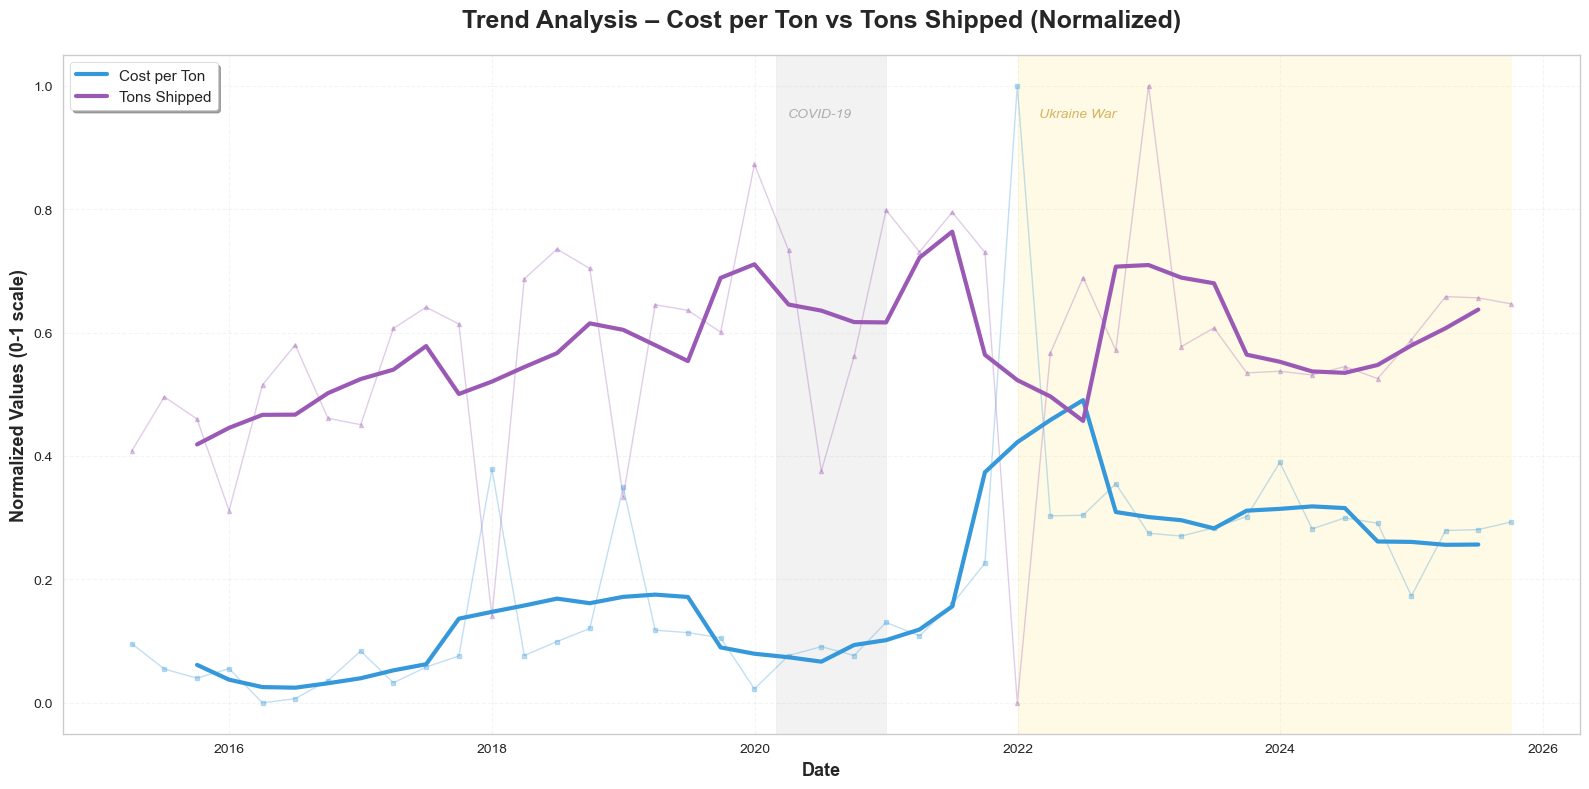

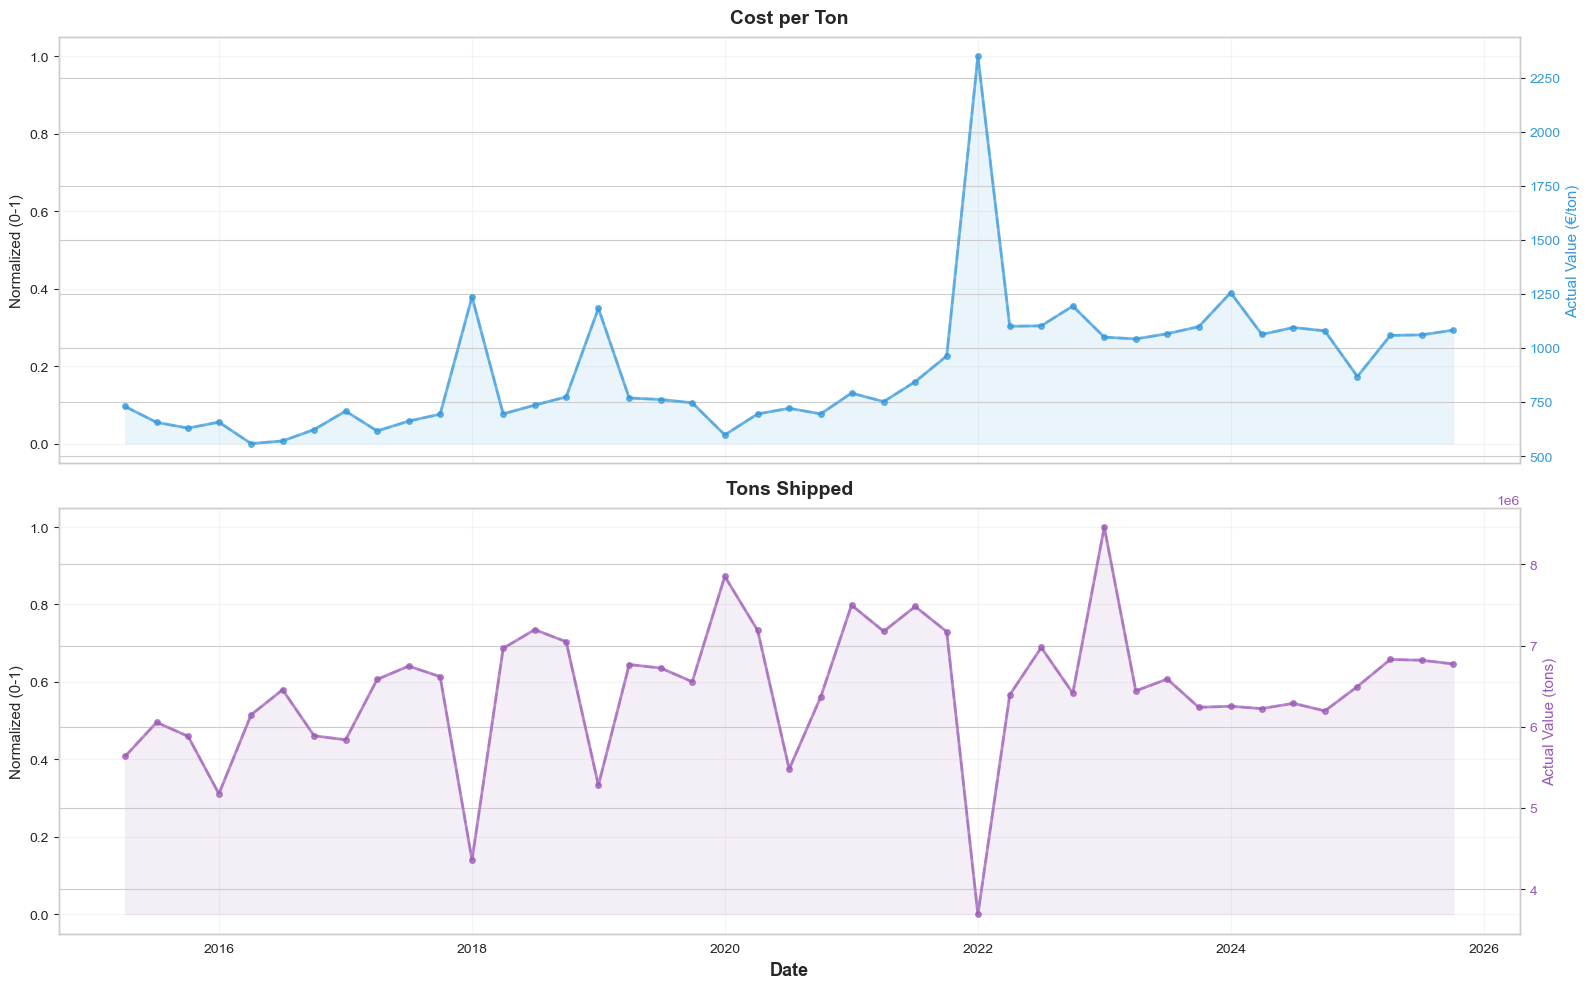

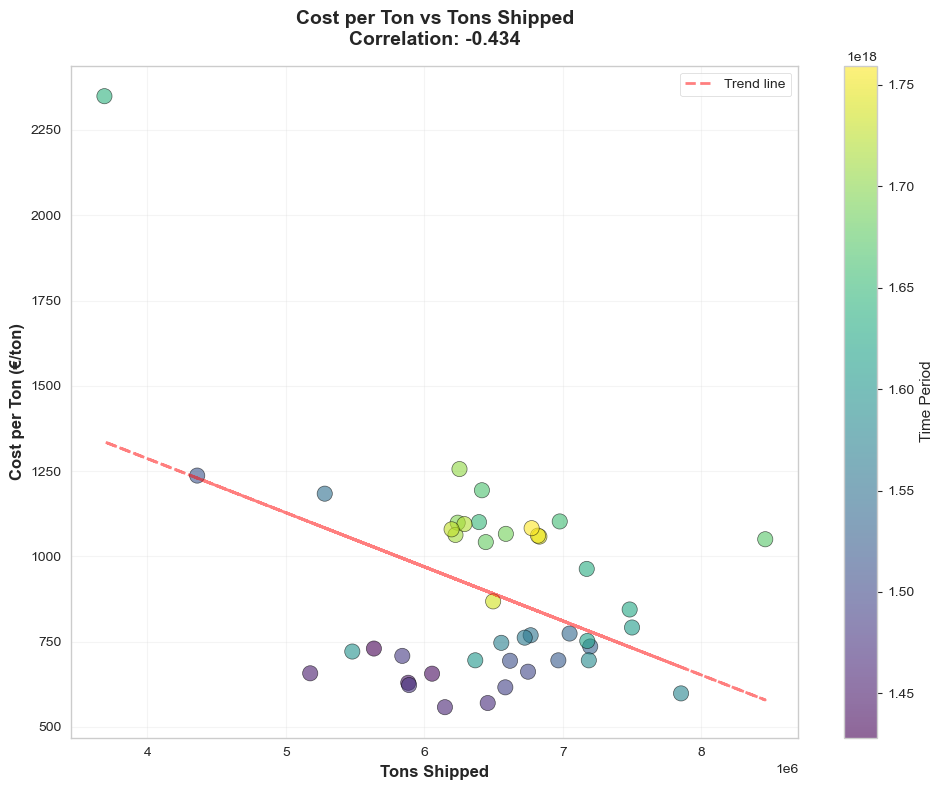


DESCRIPTIVE STATISTICS
       Y_Cost_Per_Ton  Tons_Shipped
count           43.00         43.00
mean           898.22    6447279.07
std            309.09     845817.56
min            557.68    3689000.00
25%            695.00    6172000.00
50%            773.56    6496000.00
75%           1072.47    6898500.00
max           2349.06    8461000.00

PERCENT CHANGE (last vs first)
Y_Cost_Per_Ton: +48.38%
Tons_Shipped: +20.21%

CORRELATION
Cost per Ton vs Tons Shipped: -0.434


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'


cols = ["Y_Cost_Per_Ton", "Tons_Shipped"]

#Normalization
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[cols] = scaler.fit_transform(df[cols])

#rolling average
window = 4  
for col in cols:
    df_norm[f"{col}_smooth"] = df_norm[col].rolling(window=window, center=True).mean()

#Graph
fig, ax = plt.subplots(figsize=(16, 8))

colors = {
    'Cost': '#3498DB', 
    'Tons': '#9B59B6'
}


ax.plot(df["PeriodEndDate"], df_norm["Y_Cost_Per_Ton"], 
        color=colors['Cost'], alpha=0.3, linewidth=1, marker="s", markersize=3)
ax.plot(df["PeriodEndDate"], df_norm["Tons_Shipped"],
        color=colors['Tons'], alpha=0.3, linewidth=1, marker="^", markersize=3)

ax.plot(df["PeriodEndDate"], df_norm["Y_Cost_Per_Ton_smooth"], 
        label="Cost per Ton", linewidth=3, color=colors['Cost'])
ax.plot(df["PeriodEndDate"], df_norm["Tons_Shipped_smooth"],
        label="Tons Shipped", linewidth=3, color=colors['Tons'])


ax.set_title("Trend Analysis – Cost per Ton vs Tons Shipped (Normalized)", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Date", fontsize=13, fontweight='bold')
ax.set_ylabel("Normalized Values (0-1 scale)", fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)
ax.grid(True, alpha=0.2, linestyle='--')

#Events

#COVID-19 shading (March 2020 – December 2020)
ax.axvspan(pd.Timestamp('2020-03-01'),
           pd.Timestamp('2020-12-31'),
           alpha=0.1, color='gray')

#COVID label
ax.text(pd.Timestamp('2020-04-01'), 0.95, 'COVID-19',
        fontsize=10, alpha=0.6, style='italic', color='gray')

#Ukraine War shading (from Jan 2022 onwards)
ax.axvspan(pd.Timestamp('2022-01-01'), 
           df["PeriodEndDate"].max(), 
           alpha=0.1, color='#FFD700')

#Ukraine War label
ax.text(pd.Timestamp('2022-03-01'), 0.95, 'Ukraine War',
        fontsize=10, alpha=0.6, style='italic', color='#B8860B')



plt.tight_layout()
plt.show()

#Separated graphs

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

metrics = [
    ("Y_Cost_Per_Ton", "Cost per Ton", colors['Cost'], "€/ton"),
    ("Tons_Shipped", "Tons Shipped", colors['Tons'], "tons")
]

for ax, (col, title, color, unit) in zip(axes, metrics):
   
    ax2 = ax.twinx()
    ax2.plot(df["PeriodEndDate"], df[col], color=color, linewidth=2, 
             marker='o', markersize=4, alpha=0.7)
    ax2.set_ylabel(f"Actual Value ({unit})", fontsize=11, color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    #Normalized values
    ax.plot(df["PeriodEndDate"], df_norm[col], color=color, linewidth=2, 
            alpha=0.3, linestyle='--')
    ax.fill_between(df["PeriodEndDate"], df_norm[col], alpha=0.1, color=color)
    
    ax.set_ylabel("Normalized (0-1)", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Date", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#Correlation Analysis

#Compute correlation
correlation = df["Y_Cost_Per_Ton"].corr(df["Tons_Shipped"])

fig, ax = plt.subplots(figsize=(10, 8))

#Scatter plot
scatter = ax.scatter(
    df["Tons_Shipped"], df["Y_Cost_Per_Ton"],
    c=df["PeriodEndDate"].astype(int), cmap='viridis',
    s=120, alpha=0.6, edgecolors='black', linewidth=0.5
)

ax.set_xlabel('Tons Shipped', fontsize=12, fontweight='bold')
ax.set_ylabel('Cost per Ton (€/ton)', fontsize=12, fontweight='bold')
ax.set_title(
    f'Cost per Ton vs Tons Shipped\nCorrelation: {correlation:.3f}',
    fontsize=14, fontweight='bold', pad=15
)
ax.grid(True, alpha=0.2)

#Colorbar for time
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Time Period', fontsize=11)

#Trend line
z = np.polyfit(df["Tons_Shipped"], df["Y_Cost_Per_Ton"], 1)
p = np.poly1d(z)
ax.plot(
    df["Tons_Shipped"], p(df["Tons_Shipped"]),
    "r--", alpha=0.5, linewidth=2, label='Trend line'
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

#Descriptive statistics

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
print(df[cols].describe().round(2))

print("\n" + "="*60)
print("PERCENT CHANGE (last vs first)")
print("="*60)
for col in cols:
    first = df[col].iloc[0]
    last = df[col].iloc[-1]
    pct_change = ((last - first) / first) * 100
    print(f"{col}: {pct_change:+.2f}%")

print("\n" + "="*60)
print("CORRELATION")
print("="*60)
print(f"Cost per Ton vs Tons Shipped: {correlation:.3f}")


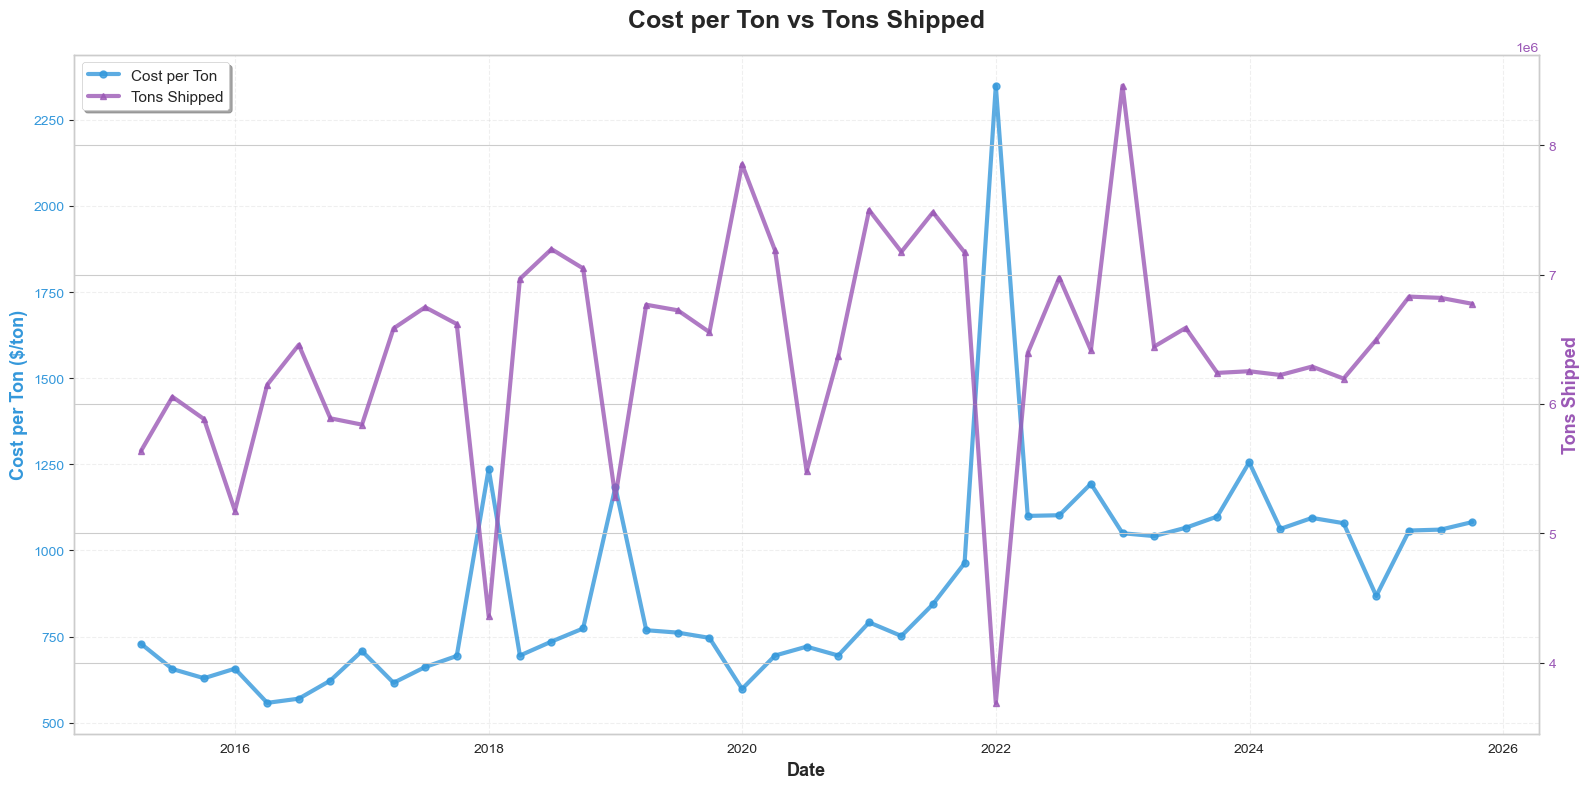

In [54]:
fig, ax1 = plt.subplots(figsize=(16, 8))

#Left axis: Cost per Ton
color_cost = '#3498DB'
ax1.set_xlabel('Date', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cost per Ton ($/ton)', color=color_cost, fontsize=13, fontweight='bold')
ax1.plot(
    df["PeriodEndDate"], df["Y_Cost_Per_Ton"],
    color=color_cost, linewidth=3, marker='o', markersize=5,
    label="Cost per Ton", alpha=0.8
)
ax1.tick_params(axis='y', labelcolor=color_cost)
ax1.grid(True, alpha=0.3, linestyle='--')

#Right axis: Tons Shipped
ax2 = ax1.twinx()
color_tons = '#9B59B6'
ax2.set_ylabel('Tons Shipped', color=color_tons, fontsize=13, fontweight='bold')
ax2.plot(
    df["PeriodEndDate"], df["Tons_Shipped"],
    color=color_tons, linewidth=3, marker='^', markersize=5,
    label="Tons Shipped", alpha=0.8
)
ax2.tick_params(axis='y', labelcolor=color_tons)

#Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper left', fontsize=11, frameon=True, shadow=True
)

plt.title("Cost per Ton vs Tons Shipped", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


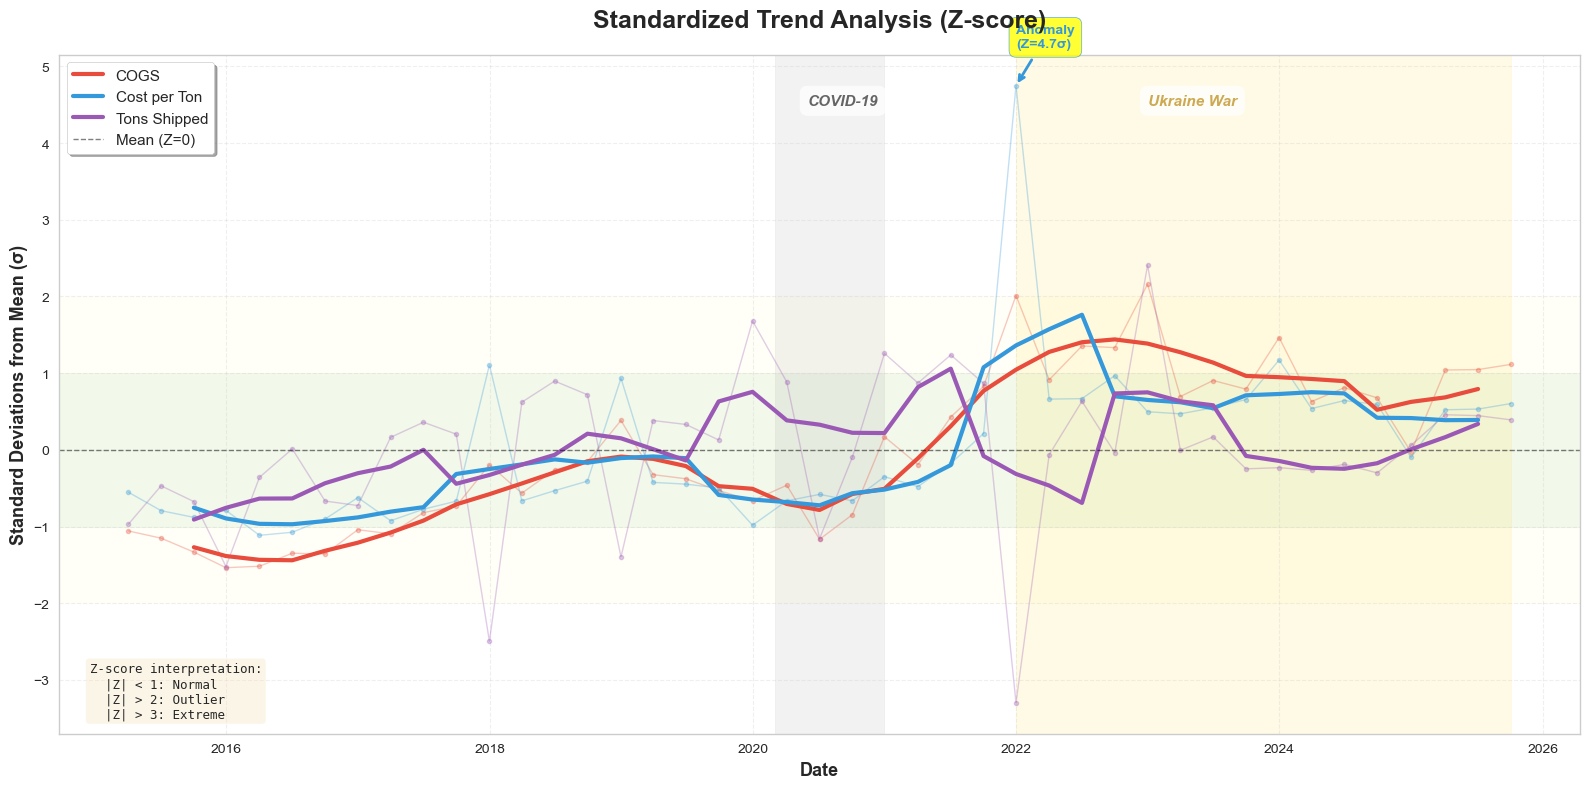


Z-SCORE STATISTICS

Max Z-scores:
COGS                : Z = +2.16σ  (on 2022-12-31)
Cost per Ton        : Z = +4.75σ  (on 2021-12-31)
Tons Shipped        : Z = +2.41σ  (on 2022-12-31)

Min Z-scores:
COGS                : Z = -1.54σ  (on 2015-12-31)
Cost per Ton        : Z = -1.11σ  (on 2016-04-02)
Tons Shipped        : Z = -3.30σ  (on 2021-12-31)

OUTLIERS (|Z| > 2)

COGS:
  2021-12-31: Z = +2.01σ  (Value: 8,665,686,000)
  2022-12-31: Z = +2.16σ  (Value: 8,884,282,000)

Cost per Ton:
  2021-12-31: Z = +4.75σ  (Value: 2,349)

Tons Shipped:
  2017-12-31: Z = -2.50σ  (Value: 4,359,000)
  2021-12-31: Z = -3.30σ  (Value: 3,689,000)
  2022-12-31: Z = +2.41σ  (Value: 8,461,000)

CORRELATION MATRIX (Z-scores)
                       Cost_of_products_sold  Y_Cost_Per_Ton  Tons_Shipped
Cost_of_products_sold                  1.000           0.795         0.146
Y_Cost_Per_Ton                         0.795           1.000        -0.434
Tons_Shipped                           0.146          -0.434   

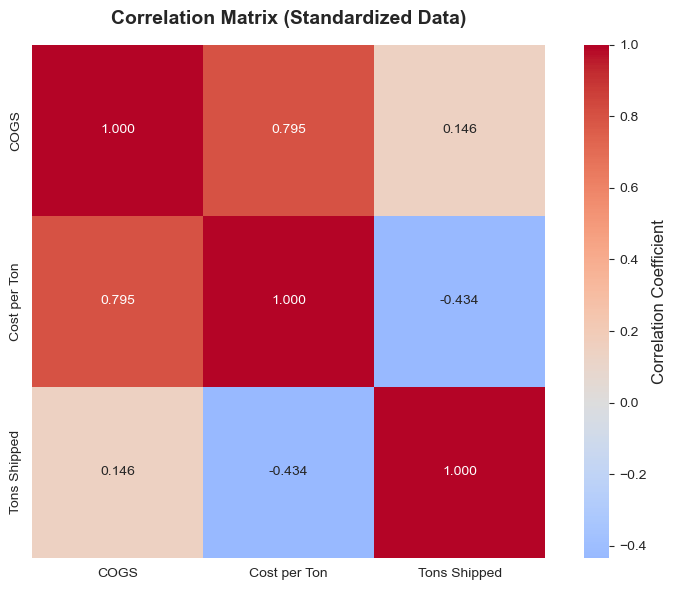

In [55]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

#STANDARDIZATION (Z-score)
cols = ["Cost_of_products_sold", "Y_Cost_Per_Ton", "Tons_Shipped"]

scaler = StandardScaler()
df_std = df.copy()
df_std[cols] = scaler.fit_transform(df[cols])

#Rolling average for trends
window = 4
for col in cols:
    df_std[f"{col}_smooth"] = df_std[col].rolling(window=window, center=True).mean()

#Main plot
fig, ax = plt.subplots(figsize=(16, 8))

#Colors
colors = {
    'Cost_of_products_sold': '#E74C3C',
    'Y_Cost_Per_Ton': '#3498DB',
    'Tons_Shipped': '#9B59B6'
}

labels = {
    'Cost_of_products_sold': 'COGS',
    'Y_Cost_Per_Ton': 'Cost per Ton',
    'Tons_Shipped': 'Tons Shipped'
}

#Plot raw lines
for col in cols:
    ax.plot(
        df["PeriodEndDate"], df_std[col],
        color=colors[col], alpha=0.3, linewidth=1,
        marker='o', markersize=3
    )

#Plot smoothed lines
for col in cols:
    ax.plot(
        df["PeriodEndDate"], df_std[f"{col}_smooth"],
        label=labels[col], linewidth=3, color=colors[col]
    )

#Zero line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Mean (Z=0)')

#±1 and ±2 std bands
ax.axhspan(-1, 1, alpha=0.05, color='green', zorder=0)
ax.axhspan(-2, 2, alpha=0.03, color='yellow', zorder=0)

#Event shading: COVID
if df["PeriodEndDate"].dt.year.max() >= 2020:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'),
               alpha=0.1, color='gray', zorder=0)
    ax.text(pd.Timestamp('2020-06-01'), 4.5, 'COVID-19',
            fontsize=11, alpha=0.7, style='italic', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

#Event shading: Ukraine War
if df["PeriodEndDate"].dt.year.max() >= 2022:
    ukraine_start = pd.Timestamp('2022-01-01')
    ukraine_end = df["PeriodEndDate"].max()

    ax.axvspan(ukraine_start, ukraine_end,
               alpha=0.1, color='#FFD700', zorder=0)
    ax.text(pd.Timestamp('2023-01-01'), 4.5, 'Ukraine War',
            fontsize=11, alpha=0.7, style='italic', fontweight='bold', color='#B8860B',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

#Highlight Cost per Ton anomaly
max_idx = df_std['Y_Cost_Per_Ton'].idxmax()
max_date = df.loc[max_idx, 'PeriodEndDate']
max_value = df_std.loc[max_idx, 'Y_Cost_Per_Ton']

ax.annotate(
    f'Anomaly\n(Z={max_value:.1f}σ)',
    xy=(max_date, max_value),
    xytext=(max_date, max_value + 0.5),
    arrowprops=dict(arrowstyle='->', color='#3498DB', lw=2),
    fontsize=10, fontweight='bold', color='#3498DB',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow',
             edgecolor='#3498DB', alpha=0.8)
)

#Formatting
ax.set_title("Standardized Trend Analysis (Z-score)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Date", fontsize=13, fontweight='bold')
ax.set_ylabel("Standard Deviations from Mean (σ)", fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')

#Z-score guide
textstr = 'Z-score interpretation:\n  |Z| < 1: Normal\n  |Z| > 2: Outlier\n  |Z| > 3: Extreme'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

#STATISTICS
print("\n" + "="*70)
print("Z-SCORE STATISTICS")
print("="*70)

print("\nMax Z-scores:")
for col in cols:
    max_z = df_std[col].max()
    max_date = df.loc[df_std[col].idxmax(), 'PeriodEndDate'].strftime('%Y-%m-%d')
    print(f"{labels[col]:20s}: Z = {max_z:+.2f}σ  (on {max_date})")

print("\nMin Z-scores:")
for col in cols:
    min_z = df_std[col].min()
    min_date = df.loc[df_std[col].idxmin(), 'PeriodEndDate'].strftime('%Y-%m-%d')
    print(f"{labels[col]:20s}: Z = {min_z:+.2f}σ  (on {min_date})")

print("\n" + "="*70)
print("OUTLIERS (|Z| > 2)")
print("="*70)
for col in cols:
    outliers = df_std[df_std[col].abs() > 2]
    if len(outliers) > 0:
        print(f"\n{labels[col]}:")
        for idx, row in outliers.iterrows():
            date = df.loc[idx, 'PeriodEndDate'].strftime('%Y-%m-%d')
            z_score = row[col]
            actual_value = df.loc[idx, col]
            print(f"  {date}: Z = {z_score:+.2f}σ  (Value: {actual_value:,.0f})")
    else:
        print(f"\n{labels[col]}: No outliers")

#CORRELATION
print("\n" + "="*70)
print("CORRELATION MATRIX (Z-scores)")
print("="*70)
corr_matrix = df_std[cols].corr()
print(corr_matrix.round(3))

#Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, square=True, ax=ax,
    xticklabels=[labels[c] for c in cols],
    yticklabels=[labels[c] for c in cols],
    cbar_kws={'label': 'Correlation Coefficient'}
)
ax.set_title('Correlation Matrix (Standardized Data)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


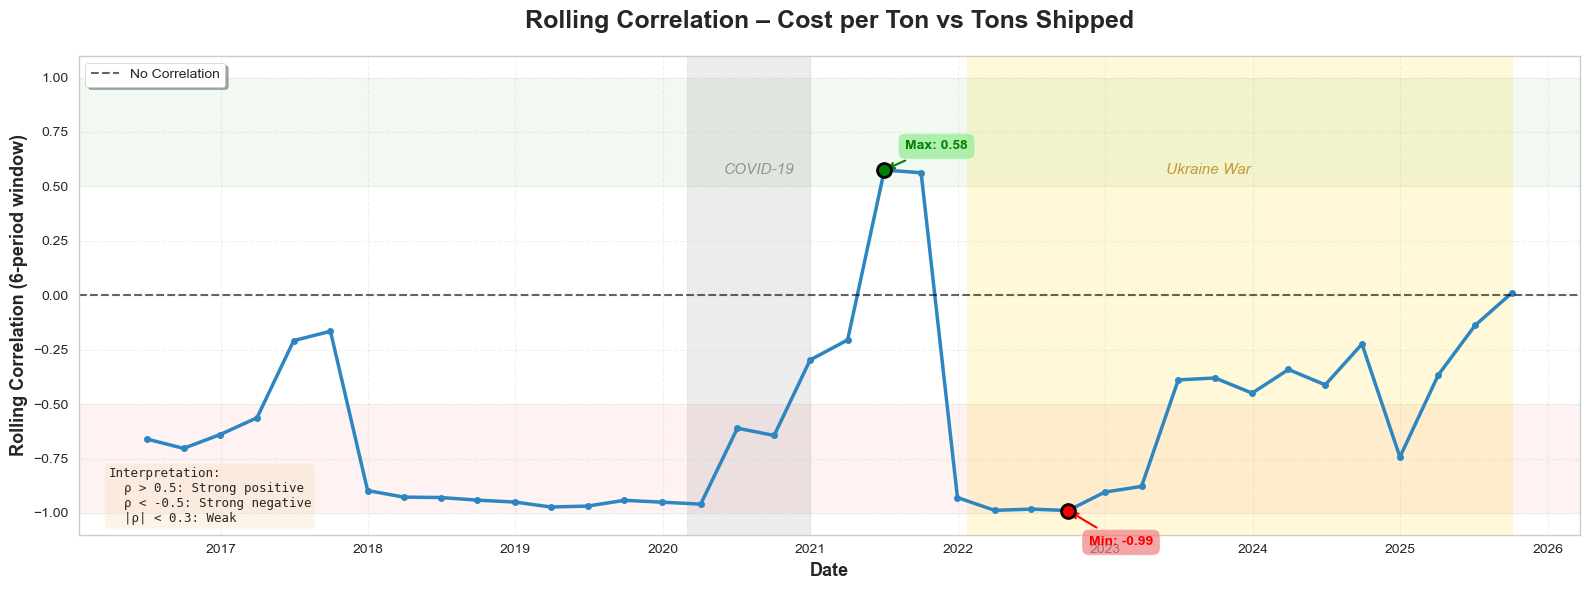


ROLLING CORRELATION ANALYSIS

Overall Statistics:
  Mean Correlation: -0.582
  Median Correlation: -0.652
  Std Deviation: 0.411
  Min Correlation: -0.989 on 2022-10-01
  Max Correlation: 0.575 on 2021-07-03

Period                         Mean Corr    Interpretation
----------------------------------------------------------------------
Pre-COVID (before 2020-03)     -0.761       Strong Negative
COVID (2020-03 to 2020-12)     -0.628       Strong Negative
Post-COVID (2021-01 to 2022-01)  0.001       Weak/None
Ukraine War (2022-01 onwards)  -0.545       Strong Negative


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Rolling correlation
window = 6
df['rolling_corr'] = df['Y_Cost_Per_Ton'].rolling(window).corr(df['Tons_Shipped'])

#Plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['PeriodEndDate'], df['rolling_corr'],
        linewidth=2.5, color='#2E86C1', marker='o', markersize=4)

#Zero line
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='No Correlation')

#Ukraine War shading
ukraine_start = pd.Timestamp('2022-01-24')
ukraine_end = df['PeriodEndDate'].max()

ax.axvspan(ukraine_start, ukraine_end, alpha=0.15, color='#FFD700', zorder=0)

#Dynamic label position
y_min, y_max = ax.get_ylim()
text_y_position = y_max * 0.85
ax.text(pd.Timestamp('2023-06-01'), text_y_position, 'Ukraine War',
        fontsize=11, alpha=0.8, color='#B8860B', style='italic')

#COVID shading
if df['PeriodEndDate'].min() <= pd.Timestamp('2020-12-31'):
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-31'),
               alpha=0.15, color='gray', zorder=0)
    ax.text(pd.Timestamp('2020-06-01'), text_y_position, 'COVID-19',
            fontsize=11, alpha=0.8, color='gray', style='italic')

#Strong correlation zones
ax.axhspan(0.5, 1.0, alpha=0.05, color='green', zorder=0)
ax.axhspan(-1.0, -0.5, alpha=0.05, color='red', zorder=0)

#Extreme correlation markers
max_corr_idx = df['rolling_corr'].idxmax()
min_corr_idx = df['rolling_corr'].idxmin()

if pd.notna(df.loc[max_corr_idx, 'rolling_corr']):
    max_date = df.loc[max_corr_idx, 'PeriodEndDate']
    max_corr = df.loc[max_corr_idx, 'rolling_corr']
    ax.scatter(max_date, max_corr, color='green', s=100, zorder=5,
               edgecolors='black', linewidths=2)
    ax.annotate(f'Max: {max_corr:.2f}',
                xy=(max_date, max_corr),
                xytext=(15, 15), textcoords='offset points',
                fontsize=10, fontweight='bold', color='green',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

if pd.notna(df.loc[min_corr_idx, 'rolling_corr']):
    min_date = df.loc[min_corr_idx, 'PeriodEndDate']
    min_corr = df.loc[min_corr_idx, 'rolling_corr']
    ax.scatter(min_date, min_corr, color='red', s=100, zorder=5,
               edgecolors='black', linewidths=2)
    ax.annotate(f'Min: {min_corr:.2f}',
                xy=(min_date, min_corr),
                xytext=(15, -25), textcoords='offset points',
                fontsize=10, fontweight='bold', color='red',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_title("Rolling Correlation – Cost per Ton vs Tons Shipped",
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Date", fontsize=13, fontweight='bold')
ax.set_ylabel("Rolling Correlation (6-period window)", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

#Interpretation box
textstr = 'Interpretation:\n  ρ > 0.5: Strong positive\n  ρ < -0.5: Strong negative\n  |ρ| < 0.3: Weak'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

#STATISTICAL ANALYSIS
print("\n" + "="*70)
print("ROLLING CORRELATION ANALYSIS")
print("="*70)

#General stats
print(f"\nOverall Statistics:")
print(f"  Mean Correlation: {df['rolling_corr'].mean():.3f}")
print(f"  Median Correlation: {df['rolling_corr'].median():.3f}")
print(f"  Std Deviation: {df['rolling_corr'].std():.3f}")
print(f"  Min Correlation: {df['rolling_corr'].min():.3f} on {df.loc[min_corr_idx, 'PeriodEndDate'].strftime('%Y-%m-%d')}")
print(f"  Max Correlation: {df['rolling_corr'].max():.3f} on {df.loc[max_corr_idx, 'PeriodEndDate'].strftime('%Y-%m-%d')}")

#Period stats
print(f"\n{'Period':<30} {'Mean Corr':<12} {'Interpretation'}")
print("-" * 70)

periods = {
    'Pre-COVID (before 2020-03)': (df['PeriodEndDate'] < '2020-03-01'),
    'COVID (2020-03 to 2020-12)': ((df['PeriodEndDate'] >= '2020-03-01') & (df['PeriodEndDate'] <= '2020-12-31')),
    'Post-COVID (2021-01 to 2022-01)': ((df['PeriodEndDate'] >= '2021-01-01') & (df['PeriodEndDate'] < '2022-01-24')),
    'Ukraine War (2022-01 onwards)': (df['PeriodEndDate'] >= '2022-01-24')
}

for period_name, mask in periods.items():
    period_data = df[mask]['rolling_corr'].dropna()
    if len(period_data) > 0:
        mean_corr = period_data.mean()
        if mean_corr > 0.5:
            interp = "Strong Positive"
        elif mean_corr > 0.3:
            interp = "Moderate Positive"
        elif mean_corr > -0.3:
            interp = "Weak/None"
        elif mean_corr > -0.5:
            interp = "Moderate Negative"
        else:
            interp = "Strong Negative"
        
        print(f"{period_name:<30} {mean_corr:>6.3f}       {interp}")


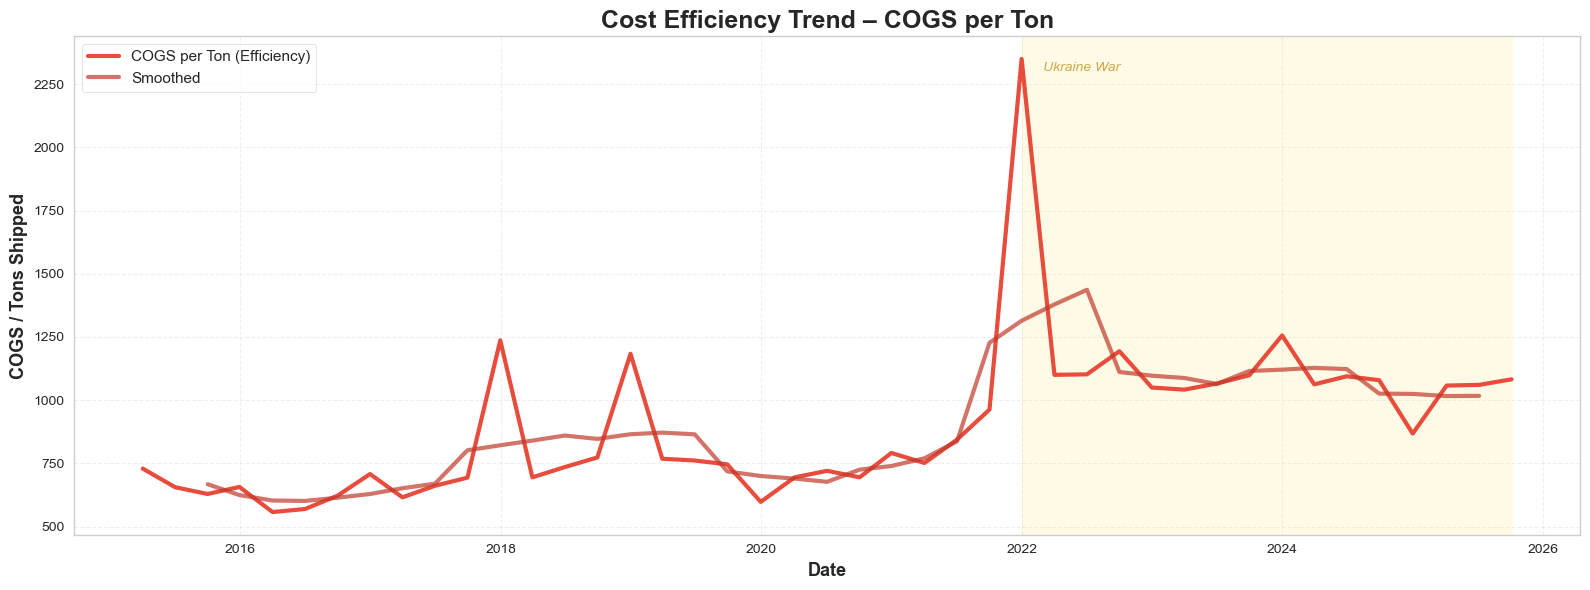

In [ ]:
import matplotlib.pyplot as plt

#Cost efficiency metric
df['Cost_Efficiency'] = df['Cost_of_products_sold'] / df['Tons_Shipped']

plt.figure(figsize=(16, 6))
plt.plot(df['PeriodEndDate'], df['Cost_Efficiency'], 
         linewidth=3, color='#E74C3C', label='COGS per Ton (Efficiency)')

#Smoothing
df['Cost_Efficiency_smooth'] = df['Cost_Efficiency'].rolling(4, center=True).mean()
plt.plot(df['PeriodEndDate'], df['Cost_Efficiency_smooth'], 
         linewidth=3, color='#C0392B', alpha=0.7, label='Smoothed')

#Ukraine War
plt.axvspan(pd.Timestamp('2022-01-01'),
            df['PeriodEndDate'].max(),
            alpha=0.1, color='#FFD700')

plt.text(pd.Timestamp('2022-03-01'), 
         df['Cost_Efficiency'].max()*0.98, 'Ukraine War',
         fontsize=10, alpha=0.7, color='#B8860B', style='italic')

plt.title("Cost Efficiency Trend – COGS per Ton", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=13, fontweight='bold')
plt.ylabel("COGS / Tons Shipped", fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
